![Cabec%CC%A7alho_notebook.png](cabecalho_notebook.png)

# Classificação de Atividade Humana com PCA

Vamos trabalhar com a base da demonstração feita em aula, mas vamos explorar um pouco melhor como é o desempenho da árvore variando o número de componentes principais.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [ ]:

BASE = "human+activity+recognition+using+smartphones/UCI HAR Dataset/UCI HAR Dataset"

filename_features = f"{BASE}/features.txt"
filename_labels   = f"{BASE}/activity_labels.txt"

filename_subtrain = f"{BASE}/train/subject_train.txt"
filename_xtrain   = f"{BASE}/train/X_train.txt"
filename_ytrain   = f"{BASE}/train/y_train.txt"

filename_subtest  = f"{BASE}/test/subject_test.txt"
filename_xtest    = f"{BASE}/test/X_test.txt"
filename_ytest    = f"{BASE}/test/y_test.txt"

features = pd.read_csv(
    filename_features, sep=r"\s+", header=None, names=['idx', 'nome_var']
)['nome_var']

contagem = {}
nomes_unicos = []
for nome in features:
    if nome in contagem:
        contagem[nome] += 1
        nomes_unicos.append(f"{nome}_{contagem[nome]}")
    else:
        contagem[nome] = 0
        nomes_unicos.append(nome)

labels    = pd.read_csv(filename_labels, sep=r"\s+", header=None, names=['cod_label', 'label'])

X_train   = pd.read_csv(filename_xtrain, sep=r"\s+", header=None, names=nomes_unicos)
y_train   = pd.read_csv(filename_ytrain, header=None, names=['cod_label'])

X_test    = pd.read_csv(filename_xtest,  sep=r"\s+", header=None, names=nomes_unicos)
y_test    = pd.read_csv(filename_ytest,  header=None, names=['cod_label'])

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

X_train: (7352, 561)
X_test : (2947, 561)


## PCA com variáveis padronizadas

Reflexão sobre a escala das variáveis:

**Variáveis em métricas muito diferentes** podem interferir na análise de componentes principais. Lembra que variância é informação pra nós? Pois bem, tipicamente se há uma variável monetária como salário, vai ter uma ordem de variabilidade bem maior que número de filhos, tempo de emprego ou qualquer variável dummy. Assim, as variáveis de maior variância tendem a "dominar" a análise. Nesses casos é comum usar a padronização das variáveis.

Faça duas análises de componentes principais para a base do HAR - com e sem padronização e compare:

- A variância explicada por componente
- A variância explicada acumulada por componente
- A variância percentual por componente
- A variância percentual acumulada por componente
- Quantas componentes você escolheria, em cada caso para explicar 90% da variância?

In [ ]:
%%time

def padroniza(s):
    if s.std() > 0:
        s = (s - s.mean())/s.std()
    return s

X_train_pad = pd.DataFrame(X_train).apply(padroniza, axis=0)
X_test_pad  = pd.DataFrame(X_test).apply(padroniza,  axis=0)

X_train_pad.head()

CPU times: total: 1.22 s
Wall time: 1.35 s


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.200628,-0.063678,-0.419600,-0.868755,-0.939377,-0.737479,-0.859758,-0.938955,-0.766385,-0.855978,...,-0.795305,0.025958,-0.276380,-0.360579,0.062935,-0.778374,-0.026079,-0.687172,0.407918,-0.007567
1,0.055944,0.031484,-0.253891,-0.875366,-0.923839,-0.849247,-0.868472,-0.921936,-0.848870,-0.871300,...,0.130605,-0.897296,-0.767938,0.133002,-0.021460,-1.218722,1.484369,-0.694091,0.409089,0.007875
2,0.073510,-0.043414,-0.076289,-0.868980,-0.907698,-0.893724,-0.863078,-0.898793,-0.896640,-0.863264,...,1.152257,-0.260860,-0.438286,-0.377815,0.391949,0.151197,1.704085,-0.702191,0.410260,0.026501
3,0.066691,-0.208407,-0.249695,-0.870566,-0.939959,-0.921743,-0.864445,-0.938060,-0.925216,-0.863264,...,1.112694,0.591005,0.463123,-0.135016,-0.033635,1.037781,-1.002951,-0.701636,0.414622,0.031712
4,0.030467,0.027585,-0.109840,-0.875128,-0.934815,-0.921281,-0.867325,-0.931726,-0.927965,-0.870201,...,-0.149567,-0.138505,-0.240296,0.340383,0.268468,1.125841,-1.276196,-0.700104,0.425434,0.045222


In [ ]:
%%time

prcomp_sem = PCA().fit(X_train)
prcomp_com = PCA().fit(X_train_pad)

CPU times: total: 1.34 s
Wall time: 859 ms


In [ ]:


n = 20

for prcomp, titulo in [(prcomp_sem, 'SEM padronização'), (prcomp_com, 'COM padronização')]:
    
    variancia          = prcomp.explained_variance_[:n]
    variancia_acum     = variancia.cumsum()
    variancia_pct      = prcomp.explained_variance_ratio_[:n] * 100
    variancia_pct_acum = variancia_pct.cumsum()

    tabela = pd.DataFrame({
        'componente'       : range(1, n+1),
        'variancia'        : variancia.round(3),
        'var_acumulada'    : variancia_acum.round(3),
        'var_pct'          : variancia_pct.round(2),
        'var_pct_acumulada': variancia_pct_acum.round(2)
    })

    print(f'\n=== {titulo} ===')
    print(tabela.to_string(index=False))


=== SEM padronização ===
 componente  variancia  var_acumulada  var_pct  var_pct_acumulada
          1     34.824         34.824    62.55              62.55
          2      2.735         37.559     4.91              67.47
          3      2.294         39.853     4.12              71.59
          4      1.044         40.897     1.87              73.46
          5      0.944         41.840     1.69              75.16
          6      0.708         42.549     1.27              76.43
          7      0.655         43.204     1.18              77.61
          8      0.595         43.799     1.07              78.68
          9      0.540         44.338     0.97              79.65
         10      0.478         44.816     0.86              80.50
         11      0.424         45.240     0.76              81.27
         12      0.374         45.615     0.67              81.94
         13      0.323         45.937     0.58              82.52
         14      0.311         46.248     0.56    

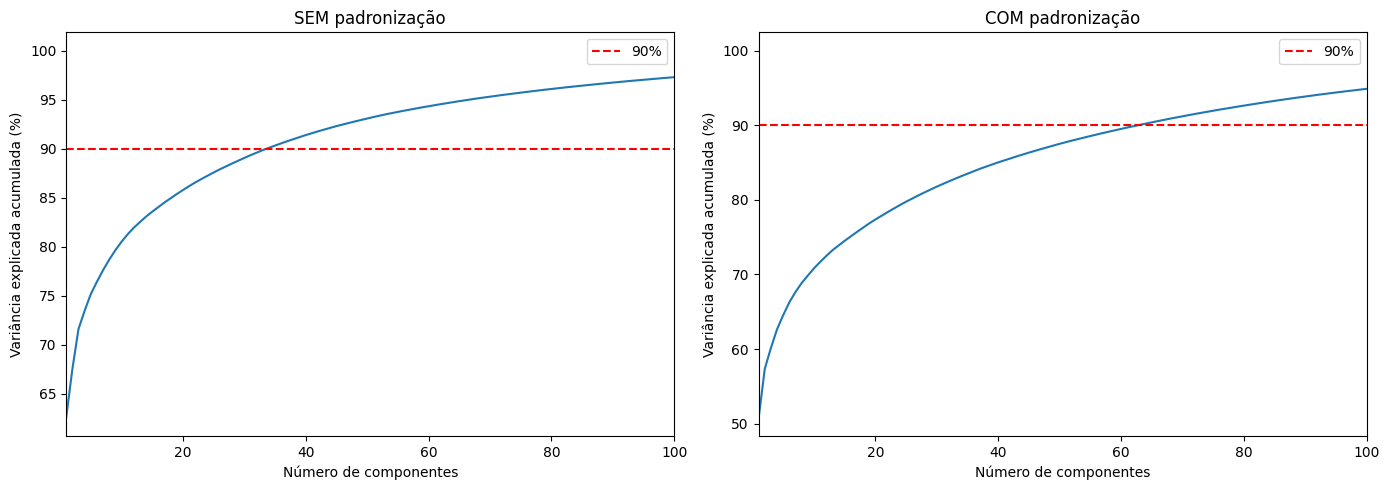

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, prcomp, titulo in [(ax1, prcomp_sem, 'SEM padronização'), (ax2, prcomp_com, 'COM padronização')]:
    acumulada = prcomp.explained_variance_ratio_.cumsum() * 100
    ax.plot(range(1, len(acumulada)+1), acumulada)
    ax.axhline(90, color='red', linestyle='--', label='90%')
    ax.set_xlim(1, 100)
    ax.set_xlabel('Número de componentes')
    ax.set_ylabel('Variância explicada acumulada (%)')
    ax.set_title(titulo)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:

for prcomp, titulo in [(prcomp_sem, 'SEM padronização'), (prcomp_com, 'COM padronização')]:
    acumulada = prcomp.explained_variance_ratio_.cumsum() * 100
    n_90 = (acumulada < 90).sum() + 1
    print(f'{titulo}: precisa de {n_90} componentes para explicar 90% da variância')

SEM padronização: precisa de 34 componentes para explicar 90% da variância
COM padronização: precisa de 63 componentes para explicar 90% da variância


## Árvore com PCA

Faça duas uma árvore de decisão com 10 componentes principais - uma com base em dados padronizados e outra sem padronizar. Utilize o ```ccp_alpha=0.001```.

Compare a acurácia na base de treino e teste.

In [ ]:
%%time

pca_sem = PCA(n_components=10).fit(X_train)
pc_treino_sem = pca_sem.transform(X_train)
pc_teste_sem  = pca_sem.transform(X_test)

clf_sem = DecisionTreeClassifier(ccp_alpha=0.001, random_state=42)
clf_sem.fit(pc_treino_sem, y_train['cod_label'])

print('=== SEM padronização ===')
print(f'Acurácia treino: {clf_sem.score(pc_treino_sem, y_train["cod_label"]):.4f}')
print(f'Acurácia teste : {clf_sem.score(pc_teste_sem,  y_test["cod_label"]):.4f}')

pca_com = PCA(n_components=10).fit(X_train_pad)
pc_treino_com = pca_com.transform(X_train_pad)
pc_teste_com  = pca_com.transform(X_test_pad)

clf_com = DecisionTreeClassifier(ccp_alpha=0.001, random_state=42)
clf_com.fit(pc_treino_com, y_train['cod_label'])

print('\n=== COM padronização ===')
print(f'Acurácia treino: {clf_com.score(pc_treino_com, y_train["cod_label"]):.4f}')
print(f'Acurácia teste : {clf_com.score(pc_teste_com,  y_test["cod_label"]):.4f}')

=== SEM padronização ===
Acurácia treino: 0.8927
Acurácia teste : 0.8242

=== COM padronização ===
Acurácia treino: 0.8587
Acurácia teste : 0.7737
CPU times: total: 1.83 s
Wall time: 1.45 s


Conclusão
Sobre a variância explicada:
Sem padronização, só 1 componente já captura 62.55% da variância, e precisei de 34 componentes para chegar em 90%. Com padronização, o primeiro componente captura 50.78% e precisei de 63 componentes para atingir os mesmos 90%.
Isso acontece porque sem padronização alguma variável com escala maior acaba dominando o PCA e concentrando muita variância nos primeiros componentes. Quando padronizamos, todas ficam na mesma régua e a variância fica mais espalhada, por isso precisa de mais componentes para explicar os mesmos 90%.
Sobre a acurácia das árvores (10 componentes):
Sem padronização: treino 89.27%, teste 82.42%
Com padronização: treino 85.87%, teste 77.37%
A versão sem padronização foi melhor. Faz sentido porque sem padronizar os 10 componentes já capturam cerca de 80% da variância, enquanto com padronização os mesmos 10 componentes capturam só 71%. Ou seja, estamos jogando fora mais informação, e o modelo sofre com isso.